In [1]:
import sys
import os
import subprocess

print("Initialisation de l'environnement...")

# --- 1. GESTION DES LIBRAIRIES EXTERNES (Téléchargement auto) ---
def install_package(package):
    print(f"Téléchargement de '{package}' en cours...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    # On essaie d'importer les librairies "publiques"
    import torchvision
    import torch
    import pandas as pd
    import time
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    import seaborn as sns
    print("Toutes les librairies externes sont déjà présentes.")

except ImportError as e:
    # Si une librairie manque (ex: seaborn), on installe tout le paquet d'un coup
    print(f"Il manque des librairies (Erreur: {e}). Installation en cours...")
    
    # On installe les classiques qui manquent souvent sur SSP Cloud
    pkgs = ["pandas", "matplotlib", "seaborn", "tqdm", "torch", "torchvision"]
    for pkg in pkgs:
        try:
            __import__(pkg) # Tente un import basique
        except ImportError:
            install_package(pkg)
            
    # On refait les imports après installation
    import torchvision
    import torch
    import pandas as pd
    import time
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    import seaborn as sns
    print("Installation terminée et librairies chargées.")


# --- 2. GESTION DE TES FICHIERS LOCAUX (Neural_networks.py, etc) ---
try:
    # C'est ici qu'on charge ton code à toi
    from Neural_networks import *
    from Comparing_results import *
    print("Tes fichiers locaux (Neural_networks, Comparing_results) sont bien chargés.")

except ImportError as e:
    print("\n" + "_"*60)
    print(f"ERREUR : Impossible de trouver le fichier '{e.name}'.")
    print("SOLUTION : Tu dois 'Uploader' (Glisser-Déposer) tes fichiers .py")
    print("(Neural_networks.py, Comparing_results.py, Helper_functions.py)")
    print("dans la barre de gauche de VS Code ou Jupyter.")
    print("_"*60 + "\n")


# --- 3. VÉRIFICATION GPU (Pour être sûr que tu vas vite) ---
if torch.cuda.is_available():
    print(f"\nEXCELLENT : GPU détecté -> {torch.cuda.get_device_name(0)}")
else:
    print("\nATTENTION : Aucun GPU détecté. L'entraînement sera lent (CPU).")

Initialisation de l'environnement...
Toutes les librairies externes sont déjà présentes.
Helper functions loaded. User device: cpu
Neural Networks loaded. User device: cpu
Tes fichiers locaux (Neural_networks, Comparing_results) sont bien chargés.

ATTENTION : Aucun GPU détecté. L'entraînement sera lent (CPU).


/Users/mignotsoline/Documents/scolaire/ENSAE/3A/DSSA/1er semestre/advanced ML/Adv_ML_Lottery_ticket_analysis_BOYINA_MIGNOT/Comparing_results.py:84: SyntaxWarning: invalid escape sequence '\{'
  plt.savefig(f"plots\{dataset_name}_comparing_{method_1_name}_vs_{method_2_name}.png")


In the Lottery Ticket Hypothesis paper, the authors propose two different iterative pruning strategies to find the winning tickets. 

Strategy 1: Iterative pruning with resetting.
1. Randomly initialize a neural network f(x; m⊙θ) where θ= θ_0 and m= 1^(|θ|) is a mask.
2. Train the network for jiterations, reaching parameters m⊙θ_j.
3. Prune s% of the parameters, creating an updated mask m' where Pm' = (Pm - s)%.
4. Reset the weights of the remaining portion of the network to their values in θ0. That is, let
θ= θ_0.
5. Let m = m' and repeat steps 2 through 4 until a sufficiently pruned network has been
obtained.


Strategy 2: Iterative pruning with continued training.
1. Randomly initialize a neural network f(x; m⊙θ) where θ= θ_0 and m= 1^(|θ|) is a mask.
2. Train the network for jiterations.
3. Prune s% of the parameters, creating an updated mask m' where Pm' = (Pm - s)%.
4. Let m= m' and repeat steps 2 and 3 until a sufficiently pruned network has been obtained.
5. Reset the weights of the remaining portion of the network to their values in θ_0. That is, let
θ= θ_0.

The difference between the two strategies is the reinitialization of the weights after pruning. 
At step 3, s% of the parameters are pruned, and we create a mask. In strategy 1, the unmasked 
weights are being reset to their value from θ_0 and then the pruning steps are being repeated.
In strategy 2, after pruning, the weights are kept at their post-trained values to then be 
trained again with only the unpruned weights. It is at the end when the model has been sufficiently 
pruned that we train it one final time with θ_0 .

According to the paper, the first strategy offers better results. In this section, we propose to 
check this claim.

In [2]:
# Détection automatique du GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


Method 1 : Ticket Gagnant (Poids d'origine).

Method 2 : Ticket Aléatoire (Poids détruits et remplacés par du hasard, car LTH=False).

But : Prouver que les poids de départ sont spéciaux.

 Beginning comparison : Winning Ticket vs Random Ticket...


Repeats:   0%|          | 0/2 [00:00<?, ?it/s]


Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 96.46%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 77.64% of the remaining weights.

--- Round 1/2 ---
Current pruning percentage (Method 1): 77.64%
Actual Global Sparsity: 77.49%
Accuracy after retraining: 96.42%

--- Round 2/2 ---
Current pruning percentage (Method 1): 95.00%
Actual Global Sparsity: 94.82%
Accuracy after retraining: 96.32%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 96.07%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 77.64% of the remaining weights.

--- Round 1/2 ---
Current pruning percentage (Method 1): 77.64%
Actual Global Sparsity: 77.49%
Accuracy after retraining: 95.56%

--- Round 2/2 ---
Current pruning percentage (Method 1): 95.00%
Actual Global Sparsity: 94.82%


Repeats:  50%|█████     | 1/2 [00:28<00:28, 28.85s/it]

Accuracy after retraining: 92.85%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 95.87%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 77.64% of the remaining weights.

--- Round 1/2 ---
Current pruning percentage (Method 1): 77.64%
Actual Global Sparsity: 77.49%
Accuracy after retraining: 96.69%

--- Round 2/2 ---
Current pruning percentage (Method 1): 95.00%
Actual Global Sparsity: 94.82%
Accuracy after retraining: 96.38%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 96.26%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 77.64% of the remaining weights.

--- Round 1/2 ---
Current pruning percentage (Method 1): 77.64%
Actual Global Sparsity: 77.49%
Accuracy after retraining: 95.74%

--- Round 2/2 ---
Current pruning percentage (Method 1): 95.00%
Actual Global Sparsity: 94.82%


Repeats: 100%|██████████| 2/2 [00:56<00:00, 28.23s/it]

Accuracy after retraining: 93.36%
Total time: 0.94 minutes


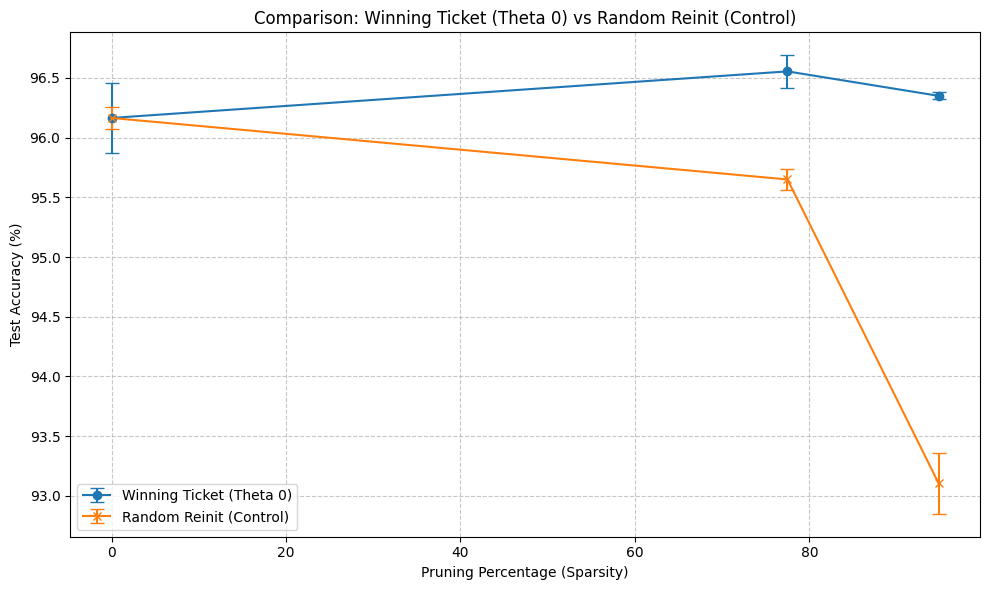

In [3]:
############## Comparing initialization after pruning ########################

# Paper's parameters
total_prune_percent = 95  
rounds = 2      
epochs_per_round = 1   
amount_of_repeats = 2   

# --- METHOD 1 : Winning Ticket ---
# top weights are reinitialized to theta0 at each round
def method_1_Winning_Ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,         # Lottery Ticket parameter - only top weights are kept
        strategy_1=True   # Reset to theta0 at each step
    )

# --- METHOD 2 : Random Re-initialization (Control Experiment) ---
# at each round, the top weights are reinitialized randomly
def method_2_Random_Ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=False         #theta_0 false-> randomly reinitialized
    )

print(" Beginning comparison : Winning Ticket vs Random Ticket...")

df_avg_acc_winning, df_avg_acc_random = comparing_methods_initialization_after_pruning(
    amount_of_repeats=amount_of_repeats, 
    rounds=rounds, 
    method_1=method_1_Winning_Ticket, 
    method_2=method_2_Random_Ticket
)

comparing_methods_plotting(
    df_avg_acc_winning, 
    df_avg_acc_random, 
    "Winning Ticket (Theta 0)", 
    "Random Reinit (Control)",
    dataset_name = 'MNIST'
)

 Lancement de la comparaison : Winning Ticket vs Random Ticket...


Repeats:   0%|          | 0/1 [00:00<?, ?it/s]


Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 97.93%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 34.29% of the remaining weights.

--- Round 1/10 ---
Current pruning percentage (Method 1): 34.29%
Actual Global Sparsity: 34.23%
Accuracy after retraining: 97.87%

--- Round 2/10 ---
Current pruning percentage (Method 1): 56.83%
Actual Global Sparsity: 56.72%
Accuracy after retraining: 98.23%

--- Round 3/10 ---
Current pruning percentage (Method 1): 71.63%
Actual Global Sparsity: 71.50%
Accuracy after retraining: 98.11%

--- Round 4/10 ---
Current pruning percentage (Method 1): 81.36%
Actual Global Sparsity: 81.21%
Accuracy after retraining: 98.21%

--- Round 5/10 ---
Current pruning percentage (Method 1): 87.75%
Actual Global Sparsity: 87.59%
Accuracy after retraining: 98.09%

--- Round 6/10 ---
Current pruning percentage (Method 1): 91.95%
Actual Global Sparsity: 91.78%
Accuracy after retraining: 98.14%

--- Round

Repeats: 100%|██████████| 1/1 [22:27<00:00, 1347.02s/it]

Accuracy after retraining: 93.15%
Total time: 22.45 minutes


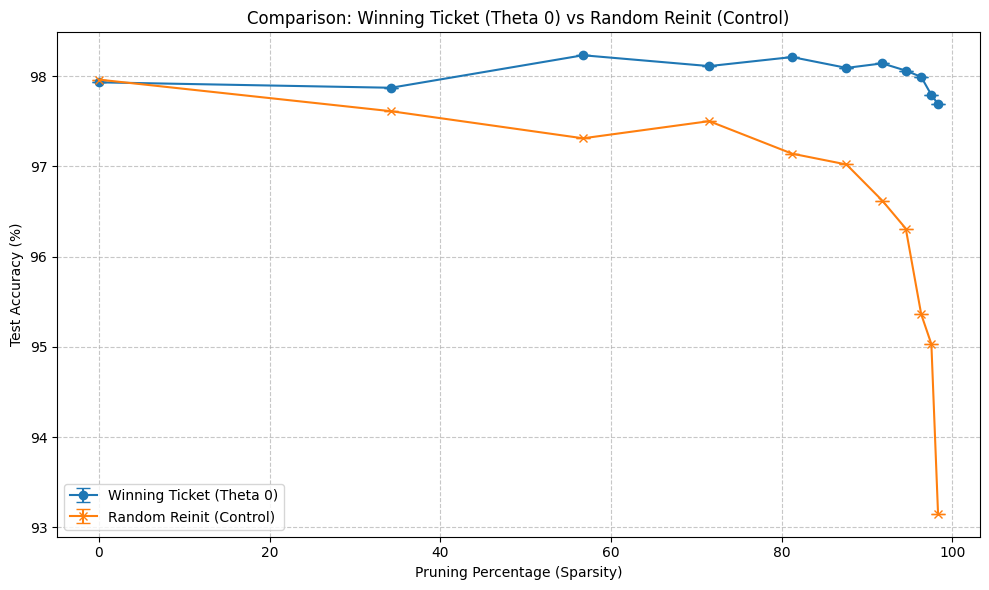

In [ ]:
############## Main experiment reproduction (Figure 1) ########################

total_prune_percent = 98.5
rounds = 10
epochs_per_round = 5
amount_of_repeats = 1

# --- METHOD 1: Winning Ticket ---
# reset remaining weights to initial values (theta_0)
def method_1_Winning_Ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,
        strategy_1=True
    )

# --- METHOD 2: Random Re-initialization (Control) ---
# same mask, random weight reinitialization
def method_2_Random_Ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=False
    )

print("Starting comparison: Winning Ticket vs Random Ticket...")

df_avg_acc_winning, df_avg_acc_random = comparing_methods_initialization_after_pruning(
    amount_of_repeats=amount_of_repeats, 
    rounds=rounds, 
    method_1=method_1_Winning_Ticket, 
    method_2=method_2_Random_Ticket
)

comparing_methods_plotting(
    df_avg_acc_winning, 
    df_avg_acc_random, 
    "Winning Ticket (Theta 0)", 
    "Random Reinit (Control)",
    dataset_name = 'MNIST'
)


 Lancement de la comparaison : Winning Ticket vs Random Ticket...


Repeats:   0%|          | 0/3 [00:00<?, ?it/s]


Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.29%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 24.42% of the remaining weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 24.42%
Actual Global Sparsity: 24.37%
Accuracy after retraining: 98.29%

--- Round 2/15 ---
Current pruning percentage (Method 1): 42.88%
Actual Global Sparsity: 42.80%
Accuracy after retraining: 98.38%

--- Round 3/15 ---
Current pruning percentage (Method 1): 56.83%
Actual Global Sparsity: 56.72%
Accuracy after retraining: 98.28%

--- Round 4/15 ---
Current pruning percentage (Method 1): 67.37%
Actual Global Sparsity: 67.24%
Accuracy after retraining: 98.21%

--- Round 5/15 ---
Current pruning percentage (Method 1): 75.34%
Actual Global Sparsity: 75.20%
Accuracy after retraining: 98.31%

--- Round 6/15 ---
Current pruning percentage (Method 1): 81.36%
Actual Global Sparsity: 81.21%
Accuracy after retraining: 98.18%

--- Round

Repeats:  33%|███▎      | 1/3 [55:20<1:50:40, 3320.20s/it]

Accuracy after retraining: 94.80%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.29%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 24.42% of the remaining weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 24.42%
Actual Global Sparsity: 24.37%
Accuracy after retraining: 98.36%

--- Round 2/15 ---
Current pruning percentage (Method 1): 42.88%
Actual Global Sparsity: 42.80%
Accuracy after retraining: 98.36%

--- Round 3/15 ---
Current pruning percentage (Method 1): 56.83%
Actual Global Sparsity: 56.72%
Accuracy after retraining: 98.39%

--- Round 4/15 ---
Current pruning percentage (Method 1): 67.37%
Actual Global Sparsity: 67.24%
Accuracy after retraining: 98.35%

--- Round 5/15 ---
Current pruning percentage (Method 1): 75.34%
Actual Global Sparsity: 75.20%
Accuracy after retraining: 98.37%

--- Round 6/15 ---
Current pruning percentage (Method 1): 81.36%
Actual Global Sparsity: 81.21%
Accuracy a

Repeats:  67%|██████▋   | 2/3 [1:50:01<54:57, 3297.42s/it]

Accuracy after retraining: 94.94%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.17%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 24.42% of the remaining weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 24.42%
Actual Global Sparsity: 24.37%
Accuracy after retraining: 98.29%

--- Round 2/15 ---
Current pruning percentage (Method 1): 42.88%
Actual Global Sparsity: 42.80%
Accuracy after retraining: 98.28%

--- Round 3/15 ---
Current pruning percentage (Method 1): 56.83%
Actual Global Sparsity: 56.72%
Accuracy after retraining: 98.40%

--- Round 4/15 ---
Current pruning percentage (Method 1): 67.37%
Actual Global Sparsity: 67.24%
Accuracy after retraining: 98.33%

--- Round 5/15 ---
Current pruning percentage (Method 1): 75.34%
Actual Global Sparsity: 75.20%
Accuracy after retraining: 98.26%

--- Round 6/15 ---
Current pruning percentage (Method 1): 81.36%
Actual Global Sparsity: 81.21%
Accuracy a

Repeats: 100%|██████████| 3/3 [2:44:03<00:00, 3281.17s/it]

Accuracy after retraining: 94.73%
Total time: 164.06 minutes


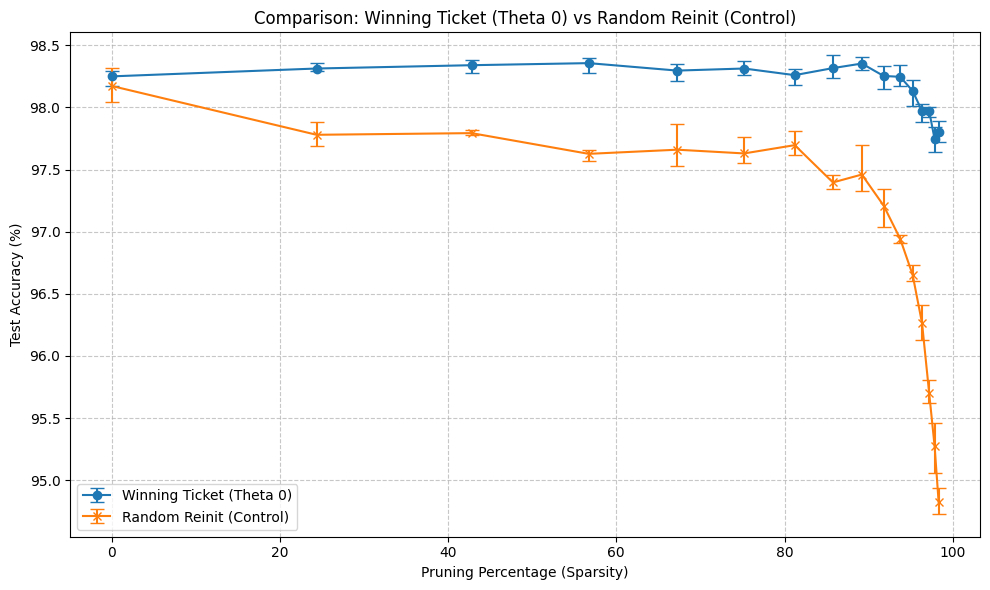

In [ ]:
############## Main experiment reproduction (Figure 1) ########################

# Paper parameters (MNIST – LeNet-300-100)
total_prune_percent = 98.5
rounds = 15
epochs_per_round = 10
amount_of_repeats = 3

# --- METHOD 1: Winning Ticket ---
# Reset remaining weights to initial values (theta_0)
def method_1_Winning_Ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,
        strategy_1=True
    )

# --- METHOD 2: Random Re-initialization (Control) ---
# Same mask, random weight reinitialization
def method_2_Random_Ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=False
    )

print("Starting comparison: Winning Ticket vs Random Ticket...")

df_avg_acc_winning, df_avg_acc_random = comparing_methods_initialization_after_pruning(
    amount_of_repeats=amount_of_repeats, 
    rounds=rounds, 
    method_1=method_1_Winning_Ticket, 
    method_2=method_2_Random_Ticket
)

comparing_methods_plotting(
    df_avg_acc_winning, 
    df_avg_acc_random, 
    "Winning Ticket (Theta 0)", 
    "Random Reinit (Control)",
    dataset_name = 'MNIST'
)

Method 1 : On remet les poids à zéro à chaque round.

Method 2 : On ne remet pas à zéro, on continue d'entraîner (Fine-tuning) et on ne remet à zéro qu'à la toute fin.

But : Voir quelle méthode d'entraînement est la plus efficace pour trouver le ticket.

In [ ]:
############## COMPARISON : STRATEGY 1 (Reset) vs STRATEGY 2 (Reset at the end) ########################

total_prune_percent = 98.5
rounds = 15
epochs_per_round = 10
amount_of_repeats = 3

# --- STRATEGY 1 : Standard LTH ---
def method_1_Strategy1():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,        
        strategy_1=True   # we reset to theta0 at each round
    )

# --- STRATEGY 2 : Reset only at the end ---
def method_2_Strategy2():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,      
        strategy_1=False   # we do NOT reset to theta0 at each round
        )

print(" Lancement de la comparaison : Strategy 1 (Reset) vs Strategy 2 (Continu)...")

df_strat1, df_strat2 = comparing_methods_initialization_after_pruning(
    amount_of_repeats=amount_of_repeats, 
    rounds=rounds, 
    method_1=method_1_Strategy1, 
    method_2=method_2_Strategy2
)

comparing_methods_plotting(
    df_strat1, 
    df_strat2, 
    "Strategy 1 (Reset)", 
    "Strategy 2 (Fine-tuning)",
    dataset_name = 'MNIST'
)

 Lancement de la comparaison : Strategy 1 (Reset) vs Strategy 2 (Continu)...


Repeats:   0%|          | 0/3 [00:00<?, ?it/s]


Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.18%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 24.42% of the remaining weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 24.42%
Actual Global Sparsity: 24.37%
Accuracy after retraining: 98.33%

--- Round 2/15 ---
Current pruning percentage (Method 1): 42.88%
Actual Global Sparsity: 42.80%
Accuracy after retraining: 98.37%

--- Round 3/15 ---
Current pruning percentage (Method 1): 56.83%
Actual Global Sparsity: 56.72%
Accuracy after retraining: 98.31%

--- Round 4/15 ---
Current pruning percentage (Method 1): 67.37%
Actual Global Sparsity: 67.24%
Accuracy after retraining: 98.41%

--- Round 5/15 ---
Current pruning percentage (Method 1): 75.34%
Actual Global Sparsity: 75.20%
Accuracy after retraining: 98.27%

--- Round 6/15 ---
Current pruning percentage (Method 1): 81.36%
Actual Global Sparsity: 81.21%
Accuracy after retraining: 98.17%

--- Round

Comparaison : Iterative Pruning (IMP) vs One-Shot Pruning
Hypothèse : L'approche progressive maintient la précision plus longtemps que l'approche brutale.

Le test : Compare l'élagage progressif (enlever 20% par tour pendant 15 tours) contre l'élagage brutal (enlever 95% d'un coup).

Le but : Montrer que l'approche itérative (IMP) trouve de meilleurs tickets gagnants que l'approche directe, surtout pour des taux de compression élevés.

🚀 Lancement : Iterative vs One-Shot...


Repeats:   0%|          | 0/3 [00:00<?, ?it/s]


Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.27%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 24.42% of the remaining weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 24.42%
Actual Global Sparsity: 24.37%
Accuracy after retraining: 98.40%

--- Round 2/15 ---
Current pruning percentage (Method 1): 42.88%
Actual Global Sparsity: 42.80%
Accuracy after retraining: 98.40%

--- Round 3/15 ---
Current pruning percentage (Method 1): 56.83%
Actual Global Sparsity: 56.72%
Accuracy after retraining: 98.32%

--- Round 4/15 ---
Current pruning percentage (Method 1): 67.37%
Actual Global Sparsity: 67.24%
Accuracy after retraining: 98.35%

--- Round 5/15 ---
Current pruning percentage (Method 1): 75.34%
Actual Global Sparsity: 75.20%
Accuracy after retraining: 98.35%

--- Round 6/15 ---
Current pruning percentage (Method 1): 81.36%
Actual Global Sparsity: 81.21%
Accuracy after retraining: 98.33%

--- Round

Repeats:  33%|███▎      | 1/3 [33:33<1:07:06, 2013.16s/it]

Accuracy after retraining: 96.57%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.23%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 24.42% of the remaining weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 24.42%
Actual Global Sparsity: 24.37%
Accuracy after retraining: 98.31%

--- Round 2/15 ---
Current pruning percentage (Method 1): 42.88%
Actual Global Sparsity: 42.80%
Accuracy after retraining: 98.24%

--- Round 3/15 ---
Current pruning percentage (Method 1): 56.83%
Actual Global Sparsity: 56.72%
Accuracy after retraining: 98.35%

--- Round 4/15 ---
Current pruning percentage (Method 1): 67.37%
Actual Global Sparsity: 67.24%
Accuracy after retraining: 98.35%

--- Round 5/15 ---
Current pruning percentage (Method 1): 75.34%
Actual Global Sparsity: 75.20%
Accuracy after retraining: 98.27%

--- Round 6/15 ---
Current pruning percentage (Method 1): 81.36%
Actual Global Sparsity: 81.21%
Accuracy a

Repeats:  67%|██████▋   | 2/3 [1:06:30<33:12, 1992.25s/it]

Accuracy after retraining: 96.75%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.25%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 24.42% of the remaining weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 24.42%
Actual Global Sparsity: 24.37%
Accuracy after retraining: 98.41%

--- Round 2/15 ---
Current pruning percentage (Method 1): 42.88%
Actual Global Sparsity: 42.80%
Accuracy after retraining: 98.35%

--- Round 3/15 ---
Current pruning percentage (Method 1): 56.83%
Actual Global Sparsity: 56.72%
Accuracy after retraining: 98.33%

--- Round 4/15 ---
Current pruning percentage (Method 1): 67.37%
Actual Global Sparsity: 67.24%
Accuracy after retraining: 98.41%

--- Round 5/15 ---
Current pruning percentage (Method 1): 75.34%
Actual Global Sparsity: 75.20%
Accuracy after retraining: 98.34%

--- Round 6/15 ---
Current pruning percentage (Method 1): 81.36%
Actual Global Sparsity: 81.21%
Accuracy a

Repeats: 100%|██████████| 3/3 [1:39:22<00:00, 1987.42s/it]

Accuracy after retraining: 96.90%
Total time: 99.37 minutes


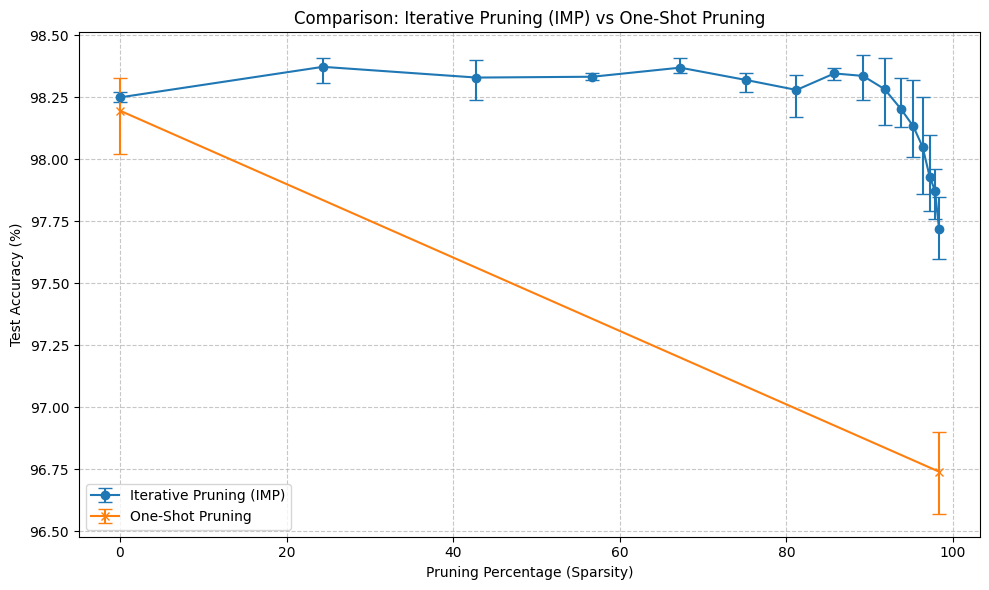

In [ ]:
############## Comparison 1: Iterative vs One-Shot Pruning #####################

# Parameters
total_prune_percent = 98.5
rounds = 15
epochs_per_round = 10
amount_of_repeats = 3

# --- METHOD 1: Iterative Magnitude Pruning (IMP) ---
# Gradual pruning over multiple rounds
def method_imp():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent,
        rounds=rounds,
        epochs_per_round=epochs_per_round,
        LTH=True, 
        one_shot=False
    )

# --- METHOD 2: One-Shot Pruning ---
# Prune all at once
def method_oneshot():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent,
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,
        one_shot=True
    )

print("Starting: Iterative vs One-Shot...")

df_imp, df_oneshot = comparing_methods_initialization_after_pruning(
    amount_of_repeats=amount_of_repeats,
    rounds=rounds,
    method_1=method_imp,
    method_2=method_oneshot
)

comparing_methods_plotting(
    df_imp, 
    df_oneshot, 
    "Iterative Pruning (IMP)", 
    "One-Shot Pruning",
    dataset_name = 'MNIST'
)


Comparaison : Dense vs Sparse (Winning Ticket)
Hypothèse : Le Winning Ticket (à 95% vide) est aussi performant que le réseau Dense (100% plein).

Le test : Compare les performances du réseau complet initial (100% des poids) contre le Winning Ticket (ex: 5% des poids restants).

Le but : Montrer qu'un réseau avec 95% de poids en moins peut atteindre la même précision (voire meilleure) que le réseau géant d'origine.

🚀 Lancement : Dense Baseline vs Sparse Winning Ticket...


Repeats:   0%|          | 0/3 [00:00<?, ?it/s]


Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.30%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 0.00% of the remaining weights.

--- Round 1/1 ---
Current pruning percentage (Method 1): 0.00%
Actual Global Sparsity: 0.00%
Accuracy after retraining: 98.17%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.13%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 24.42% of the remaining weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 24.42%
Actual Global Sparsity: 24.37%
Accuracy after retraining: 98.23%

--- Round 2/15 ---
Current pruning percentage (Method 1): 42.88%
Actual Global Sparsity: 42.80%
Accuracy after retraining: 98.24%

--- Round 3/15 ---
Current pruning percentage (Method 1): 56.83%
Actual Global Sparsity: 56.72%
Accuracy after retraining: 98.41%

--- Round 4/15 ---
Current pruning percentage (Method 1): 67.37%
Actual

Repeats:  33%|███▎      | 1/3 [34:15<1:08:31, 2055.59s/it]

Accuracy after retraining: 98.01%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.32%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 0.00% of the remaining weights.

--- Round 1/1 ---
Current pruning percentage (Method 1): 0.00%
Actual Global Sparsity: 0.00%
Accuracy after retraining: 98.05%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.15%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 24.42% of the remaining weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 24.42%
Actual Global Sparsity: 24.37%
Accuracy after retraining: 98.35%

--- Round 2/15 ---
Current pruning percentage (Method 1): 42.88%
Actual Global Sparsity: 42.80%
Accuracy after retraining: 98.37%

--- Round 3/15 ---
Current pruning percentage (Method 1): 56.83%
Actual Global Sparsity: 56.72%
Accuracy after retraining: 98.34%

--- Round 4/15 ---
Current pruning pe

Repeats:  67%|██████▋   | 2/3 [1:18:50<40:19, 2419.80s/it]

Accuracy after retraining: 97.97%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.26%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 0.00% of the remaining weights.

--- Round 1/1 ---
Current pruning percentage (Method 1): 0.00%
Actual Global Sparsity: 0.00%
Accuracy after retraining: 98.12%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 98.28%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 24.42% of the remaining weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 24.42%
Actual Global Sparsity: 24.37%
Accuracy after retraining: 98.28%

--- Round 2/15 ---
Current pruning percentage (Method 1): 42.88%
Actual Global Sparsity: 42.80%
Accuracy after retraining: 98.22%

--- Round 3/15 ---
Current pruning percentage (Method 1): 56.83%
Actual Global Sparsity: 56.72%
Accuracy after retraining: 98.30%

--- Round 4/15 ---
Current pruning pe

Repeats: 100%|██████████| 3/3 [2:07:30<00:00, 2550.05s/it]

Accuracy after retraining: 97.91%
Total time: 127.50 minutes


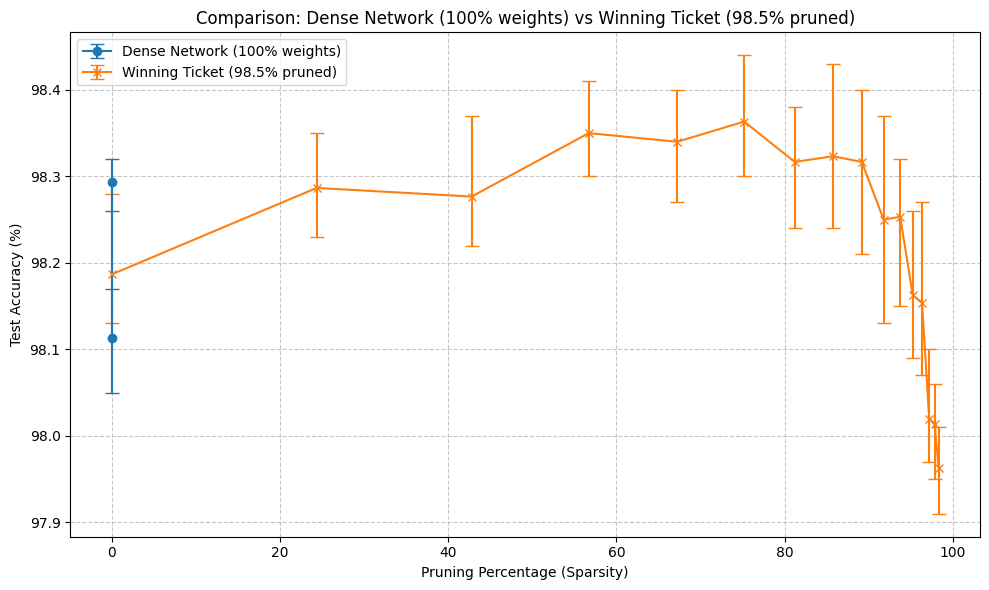

In [ ]:
############## Comparison 2: Dense vs Sparse (Winning Ticket) ##################

# Parameters
target_sparsity = 98.5
rounds = 15
epochs = 10
repeats = 3

# --- METHOD 1: Dense baseline ---
# No pruning
def method_dense_baseline():
    return iterative_pruning_MNIST(
        total_prune_percent=0,
        rounds=1,
        epochs_per_round=epochs,
        LTH=True
    )

# --- METHOD 2: Sparse Winning Ticket ---
# Pruned network using IMP
def method_sparse_ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=target_sparsity,
        rounds=rounds,
        epochs_per_round=epochs,
        LTH=True
    )

print("Starting: Dense baseline vs Sparse Winning Ticket...")

df_dense, df_sparse = comparing_methods_initialization_after_pruning(
    amount_of_repeats=repeats,
    rounds=rounds,
    method_1=method_dense_baseline,
    method_2=method_sparse_ticket
)

comparing_methods_plotting(
    df_dense, 
    df_sparse, 
    "Dense Network", 
    f"Winning Ticket ({target_sparsity}% pruned)",
    dataset_name = 'MNIST'
)


## CIFAR-Conv 2 Comparisons

In [4]:
############## Comparing initialization after pruning ########################

# Paper's parameters
total_prune_percent = 95  
rounds = 2      
epochs_per_round = 1   
amount_of_repeats = 2   

# --- METHOD 1 : Winning Ticket ---
# top weights are reinitialized to theta0 at each round
def method_1_Winning_Ticket():
    return iterative_pruning_CIFAR(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,         # Lottery Ticket parameter - only top weights are kept
        strategy_1=True   # Reset to theta0 at each step
    )

# --- METHOD 2 : Random Re-initialization (Control Experiment) ---
# at each round, the top weights are reinitialized randomly
def method_2_Random_Ticket():
    return iterative_pruning_CIFAR(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=False         #theta_0 false-> randomly reinitialized
    )

print(" Beginning comparison : Winning Ticket vs Random Ticket...")

df_avg_acc_winning, df_avg_acc_random = comparing_methods_initialization_after_pruning(
    amount_of_repeats=amount_of_repeats, 
    rounds=rounds, 
    method_1=method_1_Winning_Ticket, 
    method_2=method_2_Random_Ticket
)

comparing_methods_plotting(
    df_avg_acc_winning, 
    df_avg_acc_random, 
    "Winning Ticket (Theta 0)", 
    "Random Reinit (Control)",
    dataset_name = 'CIFAR'
)

 Beginning comparison : Winning Ticket vs Random Ticket...


Repeats:   0%|          | 0/2 [00:00<?, ?it/s]


Step 1 and 2: training the randomly initialized neural network for CIFAR.
Files already downloaded and verified
Files already downloaded and verified
   -> Optimizer used: SGD (momentum=0.9)
Initial accuracy : 29.32%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 77.64% of the weights.

--- Round 1/2 ---
Current pruning percentage (Method 1): 77.64%
Current pruning percentage: 77.58%


Repeats:   0%|          | 0/2 [07:02<?, ?it/s]
/Users/mignotsoline/Documents/scolaire/ENSAE/3A/DSSA/1er semestre/advanced ML/Adv_ML_Lottery_ticket_analysis_BOYINA_MIGNOT/Comparing_results.py:84: SyntaxWarning: invalid escape sequence '\{'
  plt.savefig(f"plots\{dataset_name}_comparing_{method_1_name}_vs_{method_2_name}.png")
<string>:84: SyntaxWarning: invalid escape sequence '\{'


KeyboardInterrupt: 